In [1]:
!pip install -U "protobuf>=6.31.1,<8"


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
!pip install -U importlib_resources


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [93]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import time
import os
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
print("TensorFlow:", tf.__version__)
print("TFDS:", tfds.__version__)

TensorFlow: 2.21.0
TFDS: 4.9.10


In [5]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 15,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'axes.labelsize': 15,
    'axes.titlesize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13
})

In [6]:
(ds_train, ds_test), ds_info = tfds.load(
    "oxford_iiit_pet",
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)
print("Training samples:", ds_info.splits["train"].num_examples)
print("Testing samples:", ds_info.splits["test"].num_examples)
print("Number of classes:", ds_info.features["label"].num_classes)

Training samples: 3680
Testing samples: 3669
Number of classes: 37


In [7]:
TOTAL_TRAIN = ds_info.splits["train"].num_examples

VAL_SIZE = int(0.20 * TOTAL_TRAIN)

ds_train_full = ds_train.shuffle(
    TOTAL_TRAIN,
    seed=42,
    reshuffle_each_iteration=False
)

ds_val = ds_train_full.take(VAL_SIZE)
ds_train = ds_train_full.skip(VAL_SIZE)

print("Training images:", TOTAL_TRAIN - VAL_SIZE)
print("Validation images:", VAL_SIZE)
print("Test images:", ds_info.splits["test"].num_examples)

Training images: 2944
Validation images: 736
Test images: 3669


In [8]:
IMG_SIZE = 224
def preprocess_image(image, label):
    image = tf.image.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )
    image = tf.cast(
        image,
        tf.float32
    )
    return image, label

In [9]:
def preprocess_image(image, label):
    image = tf.image.resize(
        image,
        (224, 224)
    )
    image = tf.cast(
        image,
        tf.float32
    )
    image = preprocess_input(image)

    return image, label

In [10]:
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

train_ds = ds_train.map(
    preprocess_image,
    num_parallel_calls=AUTOTUNE
)

val_ds = ds_val.map(
    preprocess_image,
    num_parallel_calls=AUTOTUNE
)

test_ds = ds_test.map(
    preprocess_image,
    num_parallel_calls=AUTOTUNE
)

In [11]:
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [12]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Minimum pixel value:",tf.reduce_min(images).numpy())
    print("Maximum pixel value:",tf.reduce_max(images).numpy())

I0000 00:00:1788002937.534429  411158 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


Image batch shape: (16, 224, 224, 3)
Label batch shape: (16,)
Minimum pixel value: -1.0
Maximum pixel value: 1.0


In [13]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [14]:
depthwise_count = 0
pointwise_count = 0
batchnorm_count = 0
relu6_count = 0

for layer in base_model.layers:

    if isinstance(layer, tf.keras.layers.DepthwiseConv2D):
        depthwise_count += 1

    if isinstance(layer, tf.keras.layers.Conv2D):
        if layer.kernel_size == (1, 1):
            pointwise_count += 1

    if isinstance(layer, tf.keras.layers.BatchNormalization):
        batchnorm_count += 1

    if isinstance(layer, tf.keras.layers.ReLU):
        if layer.max_value == 6:
            relu6_count += 1

print("Depthwise convolution layers:", depthwise_count)
print("Pointwise 1x1 convolution layers:", pointwise_count)
print("Batch Normalization layers:", batchnorm_count)
print("ReLU6 layers:", relu6_count)

Depthwise convolution layers: 17
Pointwise 1x1 convolution layers: 34
Batch Normalization layers: 52
ReLU6 layers: 35


In [15]:
def create_baseline_model():
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = False

    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dense(37, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

baseline_model = create_baseline_model()

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,725 (9.26 MB)

 Trainable params: 168,741 (659.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
trainable_params = np.sum([
    np.prod(v.shape)
    for v in baseline_model.trainable_weights
])

non_trainable_params = np.sum([
    np.prod(v.shape)
    for v in baseline_model.non_trainable_weights
])

print("Trainable parameters:", trainable_params)
print("Non-trainable parameters:", non_trainable_params)
print("Total parameters:", trainable_params + non_trainable_params)

Trainable parameters: 168741
Non-trainable parameters: 2257984
Total parameters: 2426725


In [17]:
EPOCHS = 10
start_time = time.time()
baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)
baseline_time = time.time() - start_time
print(f"\nBaseline training time: {baseline_time:.2f} seconds")

Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 17s 78ms/step - accuracy: 0.7612 - loss: 0.9100 - val_accuracy: 0.8995 - val_loss: 0.2914
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - accuracy: 0.9399 - loss: 0.2009 - val_accuracy: 0.8981 - val_loss: 0.2807
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 17s 88ms/step - accuracy: 0.9796 - loss: 0.0908 - val_accuracy: 0.8899 - val_loss: 0.3000
Epoch 4/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 17s 87ms/step - accuracy: 0.9935 - loss: 0.0456 - val_accuracy: 0.9144 - val_loss: 0.2591
Epoch 5/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 17s 88ms/step - accuracy: 0.9973 - loss: 0.0269 - val_accuracy: 0.9185 - val_loss: 0.2476
Epoch 6/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 19s 95ms/step - accuracy: 0.9990 - loss: 0.0184 - val_accuracy: 0.9198 - val_loss: 0.2636
Epoch 7/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 20s 105ms/step - accuracy: 0.9993 - loss: 0.0137 - val_accuracy: 0.9212 - val_loss: 0.2404
Epoch 8/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 24s 121ms/step - accuracy: 0.9993 - loss: 0.0096 

In [18]:
print("Final training accuracy   :", baseline_history.history["accuracy"][-1])
print("Final validation accuracy :", baseline_history.history["val_accuracy"][-1])
print("Final training loss       :", baseline_history.history["loss"][-1])
print("Final validation loss     :", baseline_history.history["val_loss"][-1])

Final training accuracy   : 0.9993206262588501
Final validation accuracy : 0.92798912525177
Final training loss       : 0.005858820863068104
Final validation loss     : 0.25116583704948425


In [19]:
def create_initialization_model(initializer):

    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = False

    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(
            128,
            activation="relu",
            kernel_initializer=initializer
        ),
        layers.Dense(
            37,
            activation="softmax",
            kernel_initializer=initializer
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [20]:
zero_model = create_initialization_model(
    tf.keras.initializers.Zeros()
)

zero_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,725 (9.26 MB)

 Trainable params: 168,741 (659.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [21]:
start_time = time.time()

zero_history = zero_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

zero_time = time.time() - start_time

print(f"\nZero initialization training time: {zero_time:.2f} seconds")

Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 17s 82ms/step - accuracy: 0.0211 - loss: 3.6116 - val_accuracy: 0.0217 - val_loss: 3.6117
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - accuracy: 0.0248 - loss: 3.6113 - val_accuracy: 0.0190 - val_loss: 3.6124
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 17s 86ms/step - accuracy: 0.0214 - loss: 3.6111 - val_accuracy: 0.0190 - val_loss: 3.6131
Epoch 4/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 17s 88ms/step - accuracy: 0.0224 - loss: 3.6110 - val_accuracy: 0.0190 - val_loss: 3.6138
Epoch 5/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 18s 93ms/step - accuracy: 0.0258 - loss: 3.6109 - val_accuracy: 0.0190 - val_loss: 3.6144
Epoch 6/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 21s 107ms/step - accuracy: 0.0251 - loss: 3.6108 - val_accuracy: 0.0190 - val_loss: 3.6149
Epoch 7/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 25s 130ms/step - accuracy: 0.0272 - loss: 3.6108 - val_accuracy: 0.0190 - val_loss: 3.6154
Epoch 8/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 30s 154ms/step - accuracy: 0.0285 - loss: 3.6107

In [22]:
print("Final training accuracy   :", zero_history.history["accuracy"][-1])
print("Final validation accuracy :", zero_history.history["val_accuracy"][-1])
print("Final training loss       :", zero_history.history["loss"][-1])
print("Final validation loss     :", zero_history.history["val_loss"][-1])

Final training accuracy   : 0.02921195700764656
Final validation accuracy : 0.019021738320589066
Final training loss       : 3.61064076423645
Final validation loss     : 3.6164917945861816


In [23]:
random_model = create_initialization_model(
    tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05)
)

random_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,725 (9.26 MB)

 Trainable params: 168,741 (659.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [24]:
start_time = time.time()

random_history = random_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

random_time = time.time() - start_time

print(f"\nRandom initialization training time: {random_time:.2f} seconds")

Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 21s 102ms/step - accuracy: 0.7320 - loss: 1.0745 - val_accuracy: 0.8954 - val_loss: 0.3319
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 20s 102ms/step - accuracy: 0.9280 - loss: 0.2360 - val_accuracy: 0.9035 - val_loss: 0.2843
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 21s 107ms/step - accuracy: 0.9684 - loss: 0.1246 - val_accuracy: 0.8927 - val_loss: 0.2868
Epoch 4/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 23s 118ms/step - accuracy: 0.9898 - loss: 0.0665 - val_accuracy: 0.9022 - val_loss: 0.2949
Epoch 5/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 25s 130ms/step - accuracy: 0.9966 - loss: 0.0402 - val_accuracy: 0.9158 - val_loss: 0.2923
Epoch 6/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 27s 141ms/step - accuracy: 0.9983 - loss: 0.0268 - val_accuracy: 0.9130 - val_loss: 0.2965
Epoch 7/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 28s 145ms/step - accuracy: 0.9993 - loss: 0.0198 - val_accuracy: 0.9185 - val_loss: 0.2830
Epoch 8/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 28s 142ms/step - accuracy: 0.9997 - loss: 0

In [25]:
print("Final training accuracy   :", random_history.history["accuracy"][-1])
print("Final validation accuracy :", random_history.history["val_accuracy"][-1])
print("Final training loss       :", random_history.history["loss"][-1])
print("Final validation loss     :", random_history.history["val_loss"][-1])

Final training accuracy   : 0.999660313129425
Final validation accuracy : 0.9239130616188049
Final training loss       : 0.0069962856359779835
Final validation loss     : 0.2608581781387329


In [26]:
xavier_model = create_initialization_model(
    tf.keras.initializers.GlorotUniform()
)

xavier_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,725 (9.26 MB)

 Trainable params: 168,741 (659.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [27]:
start_time = time.time()

xavier_history = xavier_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

xavier_time = time.time() - start_time

print(f"\nXavier initialization training time: {xavier_time:.2f} seconds")

Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 17s 83ms/step - accuracy: 0.7588 - loss: 0.9206 - val_accuracy: 0.9022 - val_loss: 0.3066
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 17s 86ms/step - accuracy: 0.9423 - loss: 0.1902 - val_accuracy: 0.8954 - val_loss: 0.2792
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 17s 89ms/step - accuracy: 0.9834 - loss: 0.0846 - val_accuracy: 0.8872 - val_loss: 0.3232
Epoch 4/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 20s 102ms/step - accuracy: 0.9942 - loss: 0.0461 - val_accuracy: 0.9076 - val_loss: 0.2868
Epoch 5/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 25s 126ms/step - accuracy: 0.9969 - loss: 0.0312 - val_accuracy: 0.9117 - val_loss: 0.2812
Epoch 6/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 32s 167ms/step - accuracy: 0.9986 - loss: 0.0197 - val_accuracy: 0.9253 - val_loss: 0.2482
Epoch 7/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 35s 179ms/step - accuracy: 0.9983 - loss: 0.0130 - val_accuracy: 0.9239 - val_loss: 0.2648
Epoch 8/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 32s 164ms/step - accuracy: 1.0000 - loss: 0.00

In [28]:
print("Final training accuracy   :", xavier_history.history["accuracy"][-1])
print("Final validation accuracy :", xavier_history.history["val_accuracy"][-1])
print("Final training loss       :", xavier_history.history["loss"][-1])
print("Final validation loss     :", xavier_history.history["val_loss"][-1])

Final training accuracy   : 0.9989809989929199
Final validation accuracy : 0.9307065010070801
Final training loss       : 0.006211732514202595
Final validation loss     : 0.2425280511379242


In [29]:
he_model = create_initialization_model(
    tf.keras.initializers.HeNormal()
)

he_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,725 (9.26 MB)

 Trainable params: 168,741 (659.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [30]:
start_time = time.time()

he_history = he_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

he_time = time.time() - start_time

print(f"\nHe initialization training time: {he_time:.2f} seconds")

Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 18s 83ms/step - accuracy: 0.7456 - loss: 0.9379 - val_accuracy: 0.8791 - val_loss: 0.3450
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - accuracy: 0.9351 - loss: 0.2031 - val_accuracy: 0.8967 - val_loss: 0.2915
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 16s 83ms/step - accuracy: 0.9810 - loss: 0.0886 - val_accuracy: 0.9062 - val_loss: 0.2826
Epoch 4/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 17s 88ms/step - accuracy: 0.9949 - loss: 0.0451 - val_accuracy: 0.9062 - val_loss: 0.2646
Epoch 5/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - accuracy: 0.9973 - loss: 0.0287 - val_accuracy: 0.9117 - val_loss: 0.2624
Epoch 6/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 23s 118ms/step - accuracy: 0.9986 - loss: 0.0178 - val_accuracy: 0.9185 - val_loss: 0.2586
Epoch 7/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 28s 142ms/step - accuracy: 0.9969 - loss: 0.0164 - val_accuracy: 0.9130 - val_loss: 0.2798
Epoch 8/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 29s 150ms/step - accuracy: 0.9976 - loss: 0.0120

In [31]:
print("Final training accuracy   :", he_history.history["accuracy"][-1])
print("Final validation accuracy :", he_history.history["val_accuracy"][-1])
print("Final training loss       :", he_history.history["loss"][-1])
print("Final validation loss     :", he_history.history["val_loss"][-1])

Final training accuracy   : 0.9993206262588501
Final validation accuracy : 0.92527174949646
Final training loss       : 0.006092284806072712
Final validation loss     : 0.27115732431411743


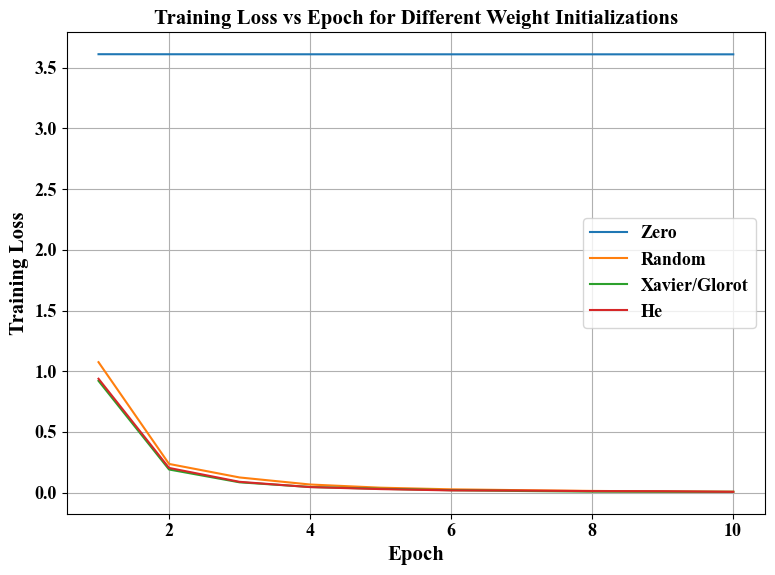

In [34]:
epochs = range(1, 11)

plt.figure(figsize=(8, 6))

plt.plot(
    epochs,
    zero_history.history["loss"],
    label="Zero"
)

plt.plot(
    epochs,
    random_history.history["loss"],
    label="Random"
)

plt.plot(
    epochs,
    xavier_history.history["loss"],
    label="Xavier/Glorot"
)

plt.plot(
    epochs,
    he_history.history["loss"],
    label="He"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch for Different Weight Initializations")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Training_Loss_vs_Epoch.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

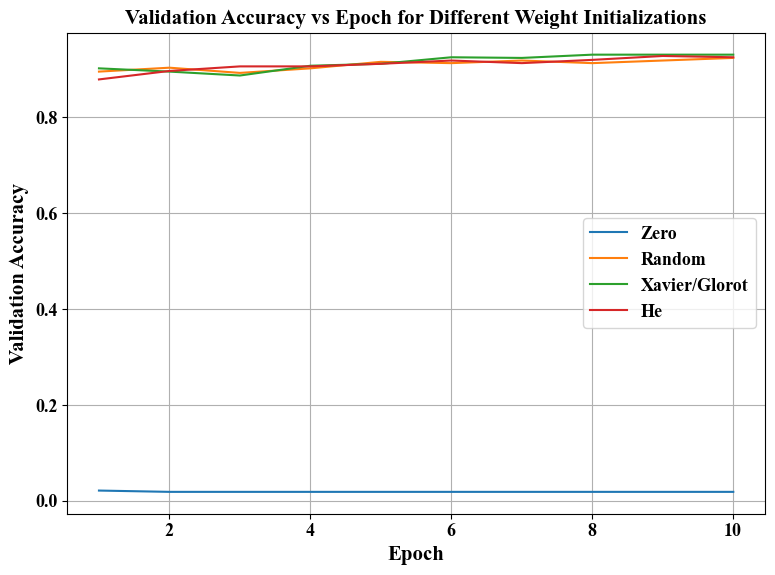

In [35]:
plt.figure(figsize=(8, 6))

plt.plot(
    epochs,
    zero_history.history["val_accuracy"],
    label="Zero"
)

plt.plot(
    epochs,
    random_history.history["val_accuracy"],
    label="Random"
)

plt.plot(
    epochs,
    xavier_history.history["val_accuracy"],
    label="Xavier/Glorot"
)

plt.plot(
    epochs,
    he_history.history["val_accuracy"],
    label="He"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs Epoch for Different Weight Initializations")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Validation_Accuracy_vs_Epoch.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

In [36]:
def create_l2_model():

    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = False

    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001)
        ),
        layers.Dense(
            37,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

l2_model = create_l2_model()

l2_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,725 (9.26 MB)

 Trainable params: 168,741 (659.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [37]:
start_time = time.time()

l2_history = l2_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

l2_time = time.time() - start_time

print(f"\nL2 training time: {l2_time:.2f} seconds")

Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 17s 81ms/step - accuracy: 0.7548 - loss: 1.1574 - val_accuracy: 0.8872 - val_loss: 0.5684
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 16s 80ms/step - accuracy: 0.9368 - loss: 0.4341 - val_accuracy: 0.8940 - val_loss: 0.5210
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - accuracy: 0.9766 - loss: 0.3095 - val_accuracy: 0.9090 - val_loss: 0.4605
Epoch 4/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 16s 83ms/step - accuracy: 0.9918 - loss: 0.2508 - val_accuracy: 0.9076 - val_loss: 0.4619
Epoch 5/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 17s 84ms/step - accuracy: 0.9976 - loss: 0.2134 - val_accuracy: 0.8981 - val_loss: 0.4828
Epoch 6/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 17s 87ms/step - accuracy: 0.9969 - loss: 0.1880 - val_accuracy: 0.9130 - val_loss: 0.4160
Epoch 7/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 19s 95ms/step - accuracy: 0.9973 - loss: 0.1667 - val_accuracy: 0.9144 - val_loss: 0.3990
Epoch 8/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 20s 103ms/step - accuracy: 0.9966 - loss: 0.1521 -

In [38]:
print("Final training accuracy   :", l2_history.history["accuracy"][-1])
print("Final validation accuracy :", l2_history.history["val_accuracy"][-1])
print("Final training loss       :", l2_history.history["loss"][-1])
print("Final validation loss     :", l2_history.history["val_loss"][-1])

Final training accuracy   : 0.9989809989929199
Final validation accuracy : 0.91847825050354
Final training loss       : 0.12363195419311523
Final validation loss     : 0.3569416403770447


In [39]:
def create_dropout_model():

    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = False

    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(
            128,
            activation="relu"
        ),
        layers.Dropout(0.3),
        layers.Dense(
            37,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

dropout_model = create_dropout_model()

dropout_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,725 (9.26 MB)

 Trainable params: 168,741 (659.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [40]:
start_time = time.time()

dropout_history = dropout_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

dropout_time = time.time() - start_time

print(f"\nDropout training time: {dropout_time:.2f} seconds")

Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 17s 79ms/step - accuracy: 0.6579 - loss: 1.2781 - val_accuracy: 0.8967 - val_loss: 0.3427
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - accuracy: 0.8821 - loss: 0.3698 - val_accuracy: 0.9117 - val_loss: 0.2638
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 16s 83ms/step - accuracy: 0.9192 - loss: 0.2531 - val_accuracy: 0.9103 - val_loss: 0.2575
Epoch 4/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 17s 84ms/step - accuracy: 0.9474 - loss: 0.1689 - val_accuracy: 0.9144 - val_loss: 0.2492
Epoch 5/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 18s 92ms/step - accuracy: 0.9681 - loss: 0.1151 - val_accuracy: 0.9158 - val_loss: 0.2358
Epoch 6/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 21s 107ms/step - accuracy: 0.9657 - loss: 0.1083 - val_accuracy: 0.9076 - val_loss: 0.2450
Epoch 7/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 24s 122ms/step - accuracy: 0.9803 - loss: 0.0695 - val_accuracy: 0.9226 - val_loss: 0.2408
Epoch 8/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 26s 132ms/step - accuracy: 0.9851 - loss: 0.0592

In [41]:
print("Final training accuracy   :", dropout_history.history["accuracy"][-1])
print("Final validation accuracy :", dropout_history.history["val_accuracy"][-1])
print("Final training loss       :", dropout_history.history["loss"][-1])
print("Final validation loss     :", dropout_history.history["val_loss"][-1])

Final training accuracy   : 0.9864130616188049
Final validation accuracy : 0.9130434989929199
Final training loss       : 0.05112750083208084
Final validation loss     : 0.2687154710292816


In [42]:
def create_batchnorm_model():

    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = False

    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(
            128,
            activation="relu"
        ),
        layers.BatchNormalization(),
        layers.Dense(
            37,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

batchnorm_model = create_batchnorm_model()

batchnorm_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,237 (9.26 MB)

 Trainable params: 168,997 (660.14 KB)

 Non-trainable params: 2,258,240 (8.61 MB)

In [43]:
start_time = time.time()

batchnorm_history = batchnorm_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

batchnorm_time = time.time() - start_time

print(f"\nBatch Normalization training time: {batchnorm_time:.2f} seconds")

Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 17s 79ms/step - accuracy: 0.7639 - loss: 0.9004 - val_accuracy: 0.8899 - val_loss: 0.3543
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - accuracy: 0.9562 - loss: 0.1979 - val_accuracy: 0.9035 - val_loss: 0.2929
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 16s 83ms/step - accuracy: 0.9939 - loss: 0.0691 - val_accuracy: 0.9130 - val_loss: 0.2788
Epoch 4/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 17s 86ms/step - accuracy: 1.0000 - loss: 0.0270 - val_accuracy: 0.9185 - val_loss: 0.2601
Epoch 5/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 19s 96ms/step - accuracy: 1.0000 - loss: 0.0149 - val_accuracy: 0.9198 - val_loss: 0.2567
Epoch 6/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 22s 111ms/step - accuracy: 1.0000 - loss: 0.0092 - val_accuracy: 0.9198 - val_loss: 0.2576
Epoch 7/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 25s 130ms/step - accuracy: 1.0000 - loss: 0.0064 - val_accuracy: 0.9226 - val_loss: 0.2600
Epoch 8/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 28s 141ms/step - accuracy: 1.0000 - loss: 0.0047

In [44]:
print("Final training accuracy   :", batchnorm_history.history["accuracy"][-1])
print("Final validation accuracy :", batchnorm_history.history["val_accuracy"][-1])
print("Final training loss       :", batchnorm_history.history["loss"][-1])
print("Final validation loss     :", batchnorm_history.history["val_loss"][-1])

Final training accuracy   : 1.0
Final validation accuracy : 0.9225543737411499
Final training loss       : 0.002877493854612112
Final validation loss     : 0.26823216676712036


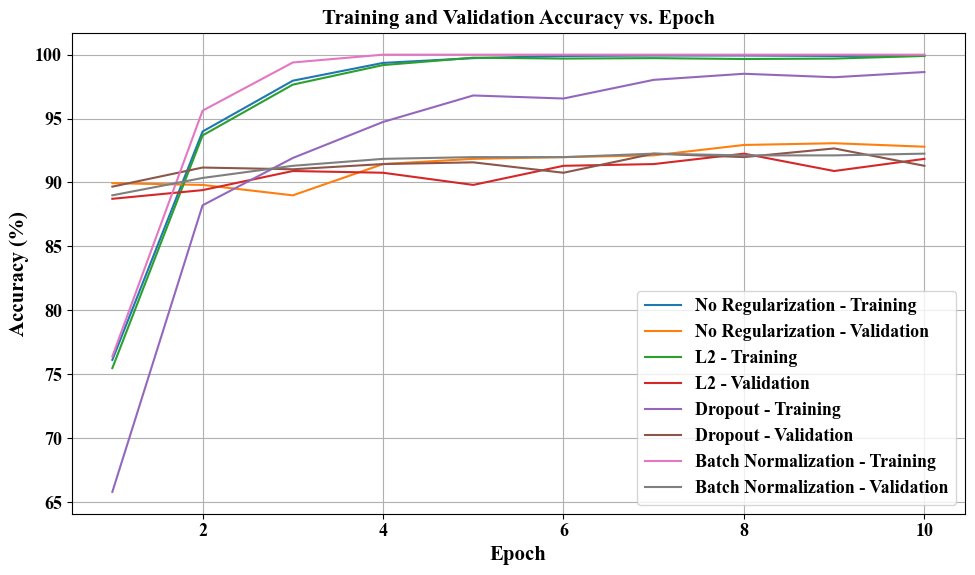

In [46]:
epochs = range(1, 11)

plt.figure(figsize=(10, 6))

plt.plot(epochs, np.array(baseline_history.history["accuracy"]) * 100,
         label="No Regularization - Training")
plt.plot(epochs, np.array(baseline_history.history["val_accuracy"]) * 100,
         label="No Regularization - Validation")

plt.plot(epochs, np.array(l2_history.history["accuracy"]) * 100,
         label="L2 - Training")
plt.plot(epochs, np.array(l2_history.history["val_accuracy"]) * 100,
         label="L2 - Validation")

plt.plot(epochs, np.array(dropout_history.history["accuracy"]) * 100,
         label="Dropout - Training")
plt.plot(epochs, np.array(dropout_history.history["val_accuracy"]) * 100,
         label="Dropout - Validation")

plt.plot(epochs, np.array(batchnorm_history.history["accuracy"]) * 100,
         label="Batch Normalization - Training")
plt.plot(epochs, np.array(batchnorm_history.history["val_accuracy"]) * 100,
         label="Batch Normalization - Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy vs. Epoch")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Training_and_Validation_Accuracy_vs_Epoch.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

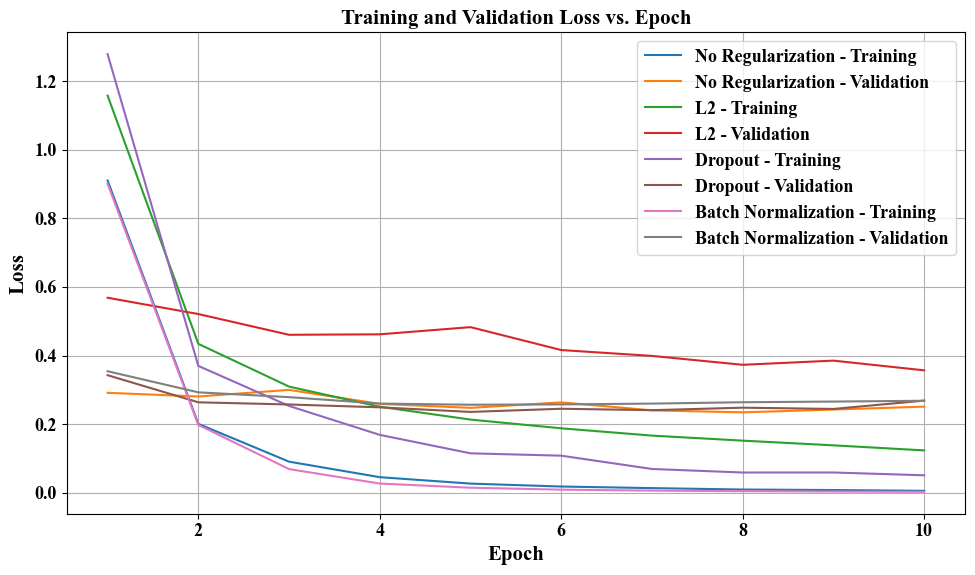

In [47]:
plt.figure(figsize=(10, 6))

plt.plot(epochs, baseline_history.history["loss"],
         label="No Regularization - Training")
plt.plot(epochs, baseline_history.history["val_loss"],
         label="No Regularization - Validation")

plt.plot(epochs, l2_history.history["loss"],
         label="L2 - Training")
plt.plot(epochs, l2_history.history["val_loss"],
         label="L2 - Validation")

plt.plot(epochs, dropout_history.history["loss"],
         label="Dropout - Training")
plt.plot(epochs, dropout_history.history["val_loss"],
         label="Dropout - Validation")

plt.plot(epochs, batchnorm_history.history["loss"],
         label="Batch Normalization - Training")
plt.plot(epochs, batchnorm_history.history["val_loss"],
         label="Batch Normalization - Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss vs. Epoch")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Training_and_Validation_Loss_vs_Epoch.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

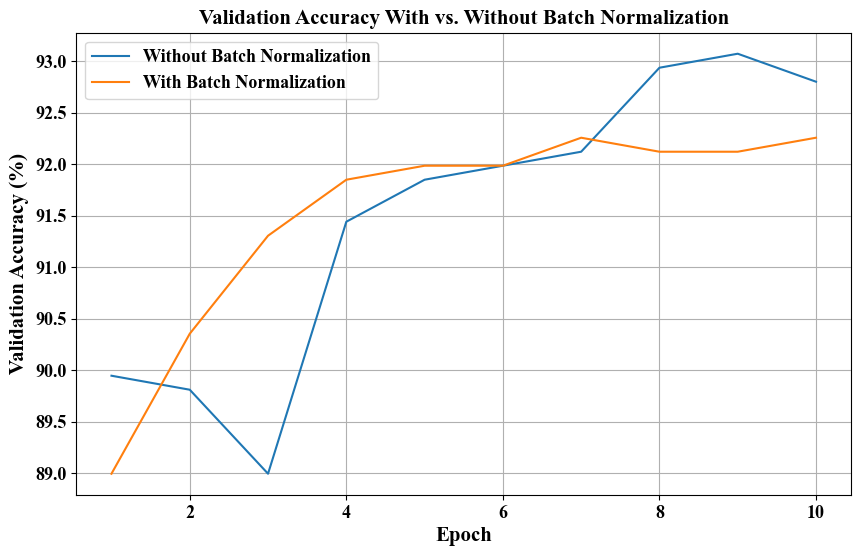

In [48]:
epochs = range(1, 11)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    np.array(baseline_history.history["val_accuracy"]) * 100,
    label="Without Batch Normalization"
)

plt.plot(
    epochs,
    np.array(batchnorm_history.history["val_accuracy"]) * 100,
    label="With Batch Normalization"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy With vs. Without Batch Normalization")
plt.legend()
plt.grid(True)
plt.savefig("Batch_Normalization_Comparison.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

In [49]:
def create_optimizer_model(optimizer):
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = False

    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dense(37, activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [50]:
optimizers = {
    "SGD": tf.keras.optimizers.SGD(learning_rate=0.01),
    "Momentum": tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    "RMSProp": tf.keras.optimizers.RMSprop(learning_rate=0.001),
    "Adam": tf.keras.optimizers.Adam(learning_rate=0.001)
}

In [51]:
optimizer_histories = {}
optimizer_times = {}

for name, optimizer in optimizers.items():

    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    model = create_optimizer_model(optimizer)

    start_time = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=10
    )

    end_time = time.time()

    optimizer_histories[name] = history
    optimizer_times[name] = end_time - start_time

    best_val_accuracy = max(history.history["val_accuracy"])
    best_epoch = np.argmax(history.history["val_accuracy"]) + 1
    final_loss = history.history["loss"][-1]

    print(name, "training time:", round(optimizer_times[name], 2), "seconds")
    print("Final training loss:", history.history["loss"][-1])
    print("Best validation accuracy:", best_val_accuracy)
    print("Best validation accuracy epoch:", best_epoch)


SGD
Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 17s 79ms/step - accuracy: 0.5044 - loss: 2.2535 - val_accuracy: 0.8043 - val_loss: 1.1066
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - accuracy: 0.8502 - loss: 0.7516 - val_accuracy: 0.8804 - val_loss: 0.5592
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - accuracy: 0.8988 - loss: 0.4512 - val_accuracy: 0.8967 - val_loss: 0.4209
Epoch 4/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - accuracy: 0.9232 - loss: 0.3396 - val_accuracy: 0.9062 - val_loss: 0.3597
Epoch 5/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 16s 84ms/step - accuracy: 0.9358 - loss: 0.2764 - val_accuracy: 0.9076 - val_loss: 0.3261
Epoch 6/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 17s 86ms/step - accuracy: 0.9474 - loss: 0.2336 - val_accuracy: 0.9103 - val_loss: 0.3044
Epoch 7/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 18s 93ms/step - accuracy: 0.9555 - loss: 0.2019 - val_accuracy: 0.9144 - val_loss: 0.2893
Epoch 8/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 20s 103ms/step - accuracy: 0.9596 - loss: 0.1

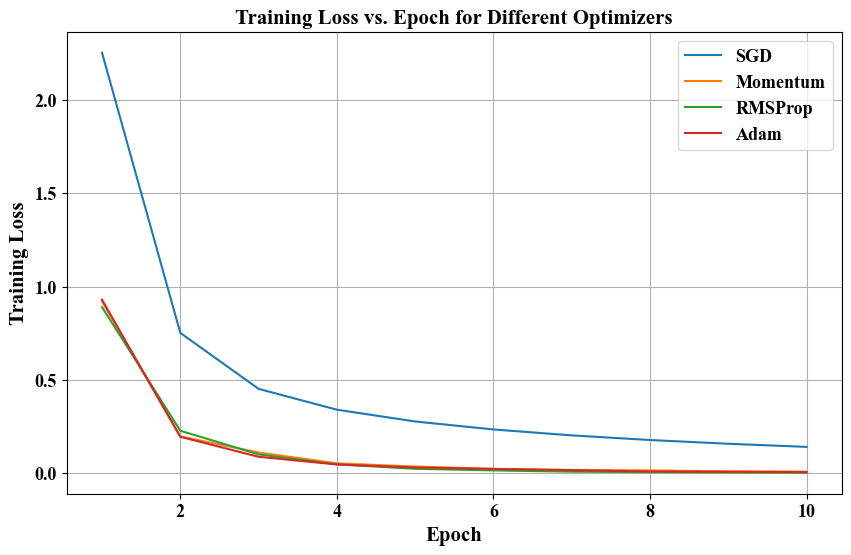

In [52]:
plt.figure(figsize=(10, 6))

for name, history in optimizer_histories.items():
    plt.plot(
        range(1, 11),
        history.history["loss"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs. Epoch for Different Optimizers")
plt.legend()
plt.grid(True)
plt.savefig("Optimizer_Training_Loss.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

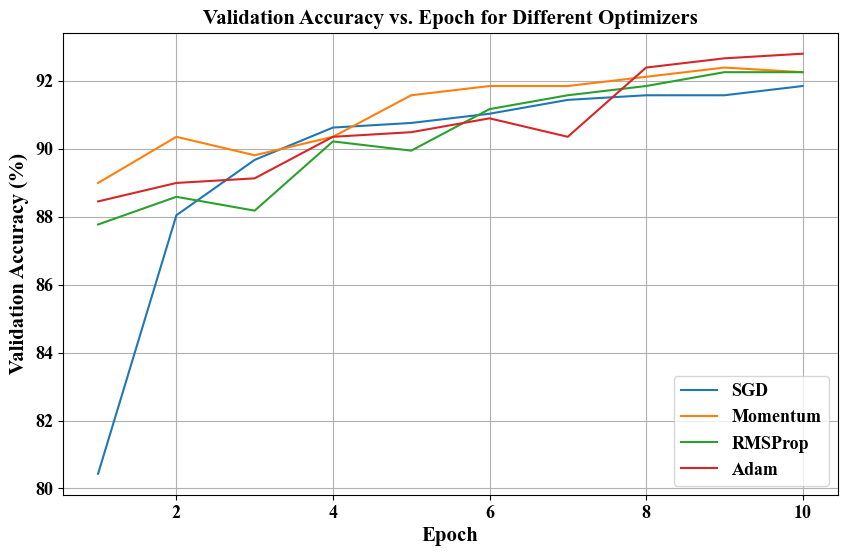

In [53]:
plt.figure(figsize=(10, 6))

for name, history in optimizer_histories.items():
    plt.plot(
        range(1, 11),
        np.array(history.history["val_accuracy"]) * 100,
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy vs. Epoch for Different Optimizers")
plt.legend()
plt.grid(True)
plt.savefig("Optimizer_Validation_Accuracy.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

In [54]:
print("Optimizer Comparison")
print("-" * 80)
print(f"{'Optimizer':<12}{'Final Loss':<15}{'Best Val Acc':<18}{'Best Epoch':<15}{'Time (s)':<12}")

for name, history in optimizer_histories.items():

    final_loss = history.history["loss"][-1]
    best_val_accuracy = max(history.history["val_accuracy"])
    best_epoch = np.argmax(history.history["val_accuracy"]) + 1
    training_time = optimizer_times[name]

    print(
        f"{name:<12}"
        f"{final_loss:<15.4f}"
        f"{best_val_accuracy * 100:<18.2f}"
        f"{best_epoch:<15}"
        f"{training_time:<12.2f}"
    )

Optimizer Comparison
--------------------------------------------------------------------------------
Optimizer   Final Loss     Best Val Acc      Best Epoch     Time (s)    
SGD         0.1402         91.85             10             183.04      
Momentum    0.0074         92.39             9              253.35      
RMSProp     0.0016         92.26             9              258.68      
Adam        0.0053         92.80             10             267.21      


In [55]:
train_raw = ds_train.map(
    preprocess_image,
    num_parallel_calls=AUTOTUNE
)
val_raw = ds_val.map(
    preprocess_image,
    num_parallel_calls=AUTOTUNE
)

In [56]:
def create_tuning_model(learning_rate=0.001, dropout_rate=0.3):
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = False

    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(37, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [57]:
learning_rates = [0.001, 0.0001]

lr_results = {}
lr_best_accuracy = {}

for lr in learning_rates:

    print("=" * 50)
    print("Learning Rate:", lr)
    print("=" * 50)

    train_data = train_raw.batch(16).prefetch(AUTOTUNE)
    val_data = val_raw.batch(16).prefetch(AUTOTUNE)

    model = create_tuning_model(
        learning_rate=lr,
        dropout_rate=0.3
    )

    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=10,
        verbose=1
    )

    lr_results[lr] = history
    lr_best_accuracy[lr] = max(history.history["val_accuracy"])

    print("Best validation accuracy:",
          lr_best_accuracy[lr] * 100)

Learning Rate: 0.001
Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 16s 78ms/step - accuracy: 0.6542 - loss: 1.2588 - val_accuracy: 0.8886 - val_loss: 0.3604
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 16s 84ms/step - accuracy: 0.8855 - loss: 0.3700 - val_accuracy: 0.9144 - val_loss: 0.2584
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - accuracy: 0.9236 - loss: 0.2498 - val_accuracy: 0.9144 - val_loss: 0.2572
Epoch 4/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - accuracy: 0.9453 - loss: 0.1758 - val_accuracy: 0.9239 - val_loss: 0.2355
Epoch 5/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 17s 88ms/step - accuracy: 0.9609 - loss: 0.1309 - val_accuracy: 0.9158 - val_loss: 0.2299
Epoch 6/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 19s 95ms/step - accuracy: 0.9718 - loss: 0.0937 - val_accuracy: 0.9212 - val_loss: 0.2282
Epoch 7/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 22s 114ms/step - accuracy: 0.9810 - loss: 0.0670 - val_accuracy: 0.9171 - val_loss: 0.2415
Epoch 8/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 25s 127ms/step - accuracy: 0

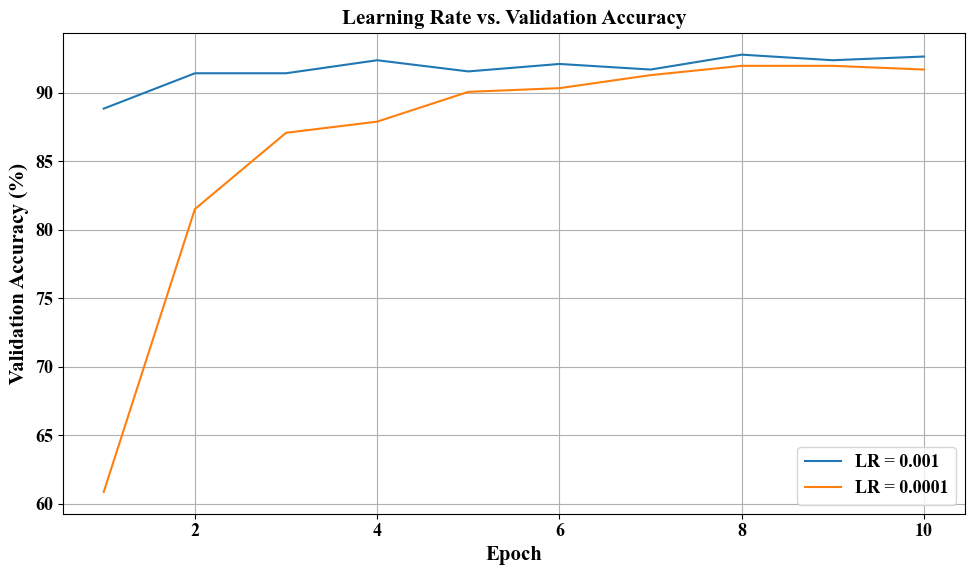

In [58]:
plt.figure(figsize=(10, 6))

for lr, history in lr_results.items():
    plt.plot(
        range(1, 11),
        np.array(history.history["val_accuracy"]) * 100,
        label=f"LR = {lr}"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Learning Rate vs. Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Learning_Rate_vs_Validation_Accuracy.eps",format="eps",dpi=600)
plt.show()

In [59]:
batch_sizes = [16, 32, 64]

batch_results = {}
batch_best_accuracy = {}

for batch_size in batch_sizes:

    print("=" * 50)
    print("Batch Size:", batch_size)
    print("=" * 50)

    train_data = train_raw.batch(batch_size).prefetch(AUTOTUNE)
    val_data = val_raw.batch(batch_size).prefetch(AUTOTUNE)

    model = create_tuning_model(
        learning_rate=0.001,
        dropout_rate=0.3
    )

    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=10,
        verbose=1
    )

    batch_results[batch_size] = history
    batch_best_accuracy[batch_size] = max(
        history.history["val_accuracy"]
    )

    print("Best validation accuracy:",
          batch_best_accuracy[batch_size] * 100)

Batch Size: 16
Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 17s 83ms/step - accuracy: 0.6525 - loss: 1.2890 - val_accuracy: 0.8940 - val_loss: 0.3554
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 18s 90ms/step - accuracy: 0.8791 - loss: 0.3789 - val_accuracy: 0.9008 - val_loss: 0.3143
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 19s 95ms/step - accuracy: 0.9164 - loss: 0.2595 - val_accuracy: 0.9076 - val_loss: 0.2785
Epoch 4/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 20s 103ms/step - accuracy: 0.9453 - loss: 0.1754 - val_accuracy: 0.9130 - val_loss: 0.2431
Epoch 5/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 22s 113ms/step - accuracy: 0.9606 - loss: 0.1259 - val_accuracy: 0.9158 - val_loss: 0.2571
Epoch 6/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 26s 131ms/step - accuracy: 0.9657 - loss: 0.1029 - val_accuracy: 0.9158 - val_loss: 0.2631
Epoch 7/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 26s 131ms/step - accuracy: 0.9786 - loss: 0.0790 - val_accuracy: 0.9226 - val_loss: 0.2339
Epoch 8/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 25s 129ms/step - accuracy: 0.98

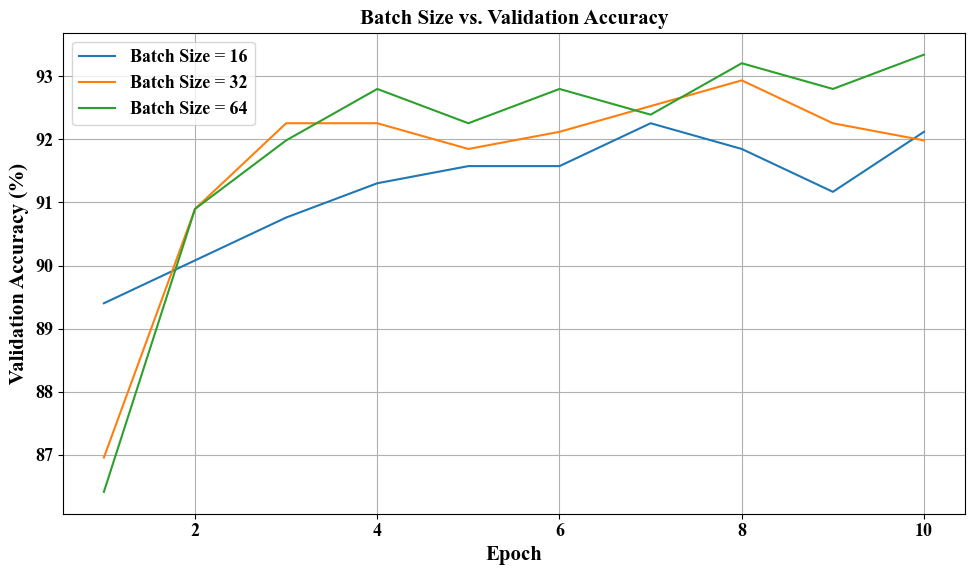

In [60]:
plt.figure(figsize=(10, 6))

for batch_size, history in batch_results.items():
    plt.plot(
        range(1, 11),
        np.array(history.history["val_accuracy"]) * 100,
        label=f"Batch Size = {batch_size}"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Batch Size vs. Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Batch_Size_vs_Validation_Accuracy.eps",format="eps",dpi=600)
plt.show()

In [61]:
dropout_rates = [0, 0.25, 0.5]

dropout_results = {}
dropout_best_accuracy = {}

for dropout_rate in dropout_rates:

    print("=" * 50)
    print("Dropout Rate:", dropout_rate)
    print("=" * 50)

    train_data = train_raw.batch(16).prefetch(AUTOTUNE)
    val_data = val_raw.batch(16).prefetch(AUTOTUNE)

    model = create_tuning_model(
        learning_rate=0.001,
        dropout_rate=dropout_rate
    )

    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=10,
        verbose=1
    )

    dropout_results[dropout_rate] = history
    dropout_best_accuracy[dropout_rate] = max(
        history.history["val_accuracy"]
    )

    print("Best validation accuracy:",
          dropout_best_accuracy[dropout_rate] * 100)

Dropout Rate: 0
Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 16s 78ms/step - accuracy: 0.7554 - loss: 0.9127 - val_accuracy: 0.8940 - val_loss: 0.3012
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 16s 80ms/step - accuracy: 0.9389 - loss: 0.1966 - val_accuracy: 0.8954 - val_loss: 0.2681
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - accuracy: 0.9827 - loss: 0.0830 - val_accuracy: 0.8981 - val_loss: 0.2868
Epoch 4/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 16s 84ms/step - accuracy: 0.9969 - loss: 0.0408 - val_accuracy: 0.9076 - val_loss: 0.2710
Epoch 5/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 17s 86ms/step - accuracy: 0.9966 - loss: 0.0304 - val_accuracy: 0.9130 - val_loss: 0.2752
Epoch 6/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 19s 96ms/step - accuracy: 0.9993 - loss: 0.0177 - val_accuracy: 0.9158 - val_loss: 0.2646
Epoch 7/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 22s 111ms/step - accuracy: 0.9980 - loss: 0.0146 - val_accuracy: 0.9049 - val_loss: 0.2775
Epoch 8/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 25s 127ms/step - accuracy: 1.0000

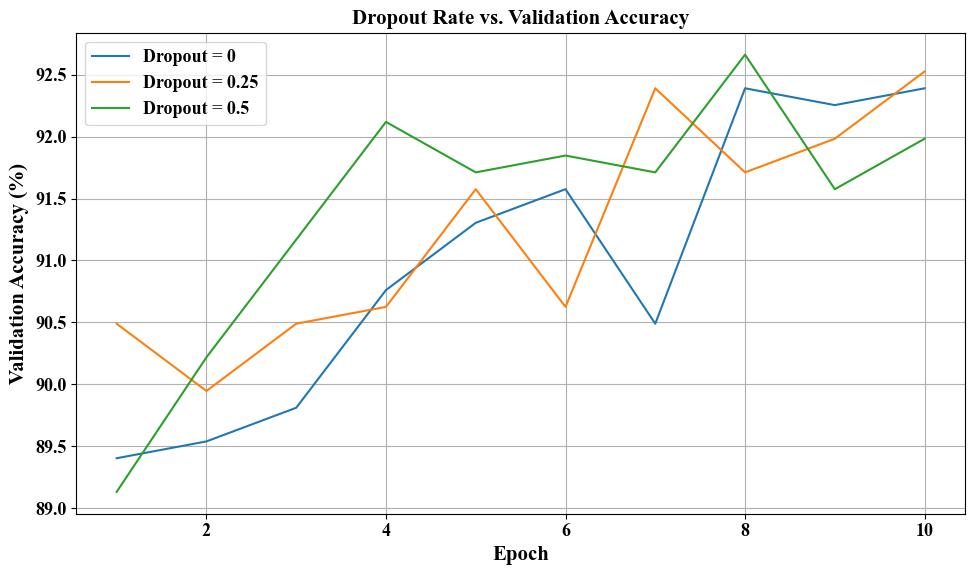

In [62]:
plt.figure(figsize=(10, 6))

for dropout_rate, history in dropout_results.items():
    plt.plot(
        range(1, 11),
        np.array(history.history["val_accuracy"]) * 100,
        label=f"Dropout = {dropout_rate}"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Dropout Rate vs. Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Dropout_Rate_vs_Validation_Accuracy.eps",format="eps",dpi=600)
plt.show()

In [63]:
def create_feature_extraction_model():
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = False

    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dense(37, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [64]:
feature_model = create_feature_extraction_model()
feature_model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_20     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,725 (9.26 MB)

 Trainable params: 168,741 (659.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [65]:
start_time = time.time()

feature_history = feature_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

feature_extraction_time = time.time() - start_time

print("Feature Extraction training time:", feature_extraction_time, "seconds")

Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 17s 78ms/step - accuracy: 0.7653 - loss: 0.8794 - val_accuracy: 0.8981 - val_loss: 0.3135
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 16s 79ms/step - accuracy: 0.9423 - loss: 0.1928 - val_accuracy: 0.8967 - val_loss: 0.2879
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - accuracy: 0.9783 - loss: 0.0861 - val_accuracy: 0.8995 - val_loss: 0.3065
Epoch 4/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - accuracy: 0.9939 - loss: 0.0438 - val_accuracy: 0.9008 - val_loss: 0.3158
Epoch 5/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 16s 83ms/step - accuracy: 0.9949 - loss: 0.0318 - val_accuracy: 0.9090 - val_loss: 0.2750
Epoch 6/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 17s 86ms/step - accuracy: 0.9973 - loss: 0.0202 - val_accuracy: 0.9049 - val_loss: 0.2777
Epoch 7/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 18s 91ms/step - accuracy: 0.9986 - loss: 0.0132 - val_accuracy: 0.9035 - val_loss: 0.2857
Epoch 8/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - accuracy: 0.9986 - loss: 0.0096 -

In [67]:
fine_tune_model = create_feature_extraction_model()

fine_tune_base = fine_tune_model.layers[0]

fine_tune_base.trainable = True

for layer in fine_tune_base.layers[:-30]:
    layer.trainable = False

for layer in fine_tune_base.layers[-30:]:
    layer.trainable = True

print("Total MobileNetV2 layers:", len(fine_tune_base.layers))
print("Trainable MobileNetV2 layers:", sum(layer.trainable for layer in fine_tune_base.layers))

Total MobileNetV2 layers: 154
Trainable MobileNetV2 layers: 30


In [68]:
fine_tune_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [69]:
fine_tune_model.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_22     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,725 (9.26 MB)

 Trainable params: 1,695,141 (6.47 MB)

 Non-trainable params: 731,584 (2.79 MB)

In [70]:
start_time = time.time()

fine_tune_history = fine_tune_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

fine_tuning_time = time.time() - start_time

print("Fine-Tuning training time:", fine_tuning_time, "seconds")

Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 22s 101ms/step - accuracy: 0.1060 - loss: 3.4092 - val_accuracy: 0.2677 - val_loss: 2.9929
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 21s 109ms/step - accuracy: 0.4474 - loss: 2.5867 - val_accuracy: 0.5720 - val_loss: 2.1936
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 20s 105ms/step - accuracy: 0.6929 - loss: 1.8377 - val_accuracy: 0.7228 - val_loss: 1.4914
Epoch 4/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 21s 106ms/step - accuracy: 0.8149 - loss: 1.2683 - val_accuracy: 0.8071 - val_loss: 1.0353
Epoch 5/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 22s 115ms/step - accuracy: 0.8736 - loss: 0.9059 - val_accuracy: 0.8438 - val_loss: 0.7762
Epoch 6/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 26s 136ms/step - accuracy: 0.9029 - loss: 0.6825 - val_accuracy: 0.8655 - val_loss: 0.6290
Epoch 7/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 30s 155ms/step - accuracy: 0.9236 - loss: 0.5356 - val_accuracy: 0.8791 - val_loss: 0.5400
Epoch 8/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 33s 169ms/step - accuracy: 0.9446 - loss: 0

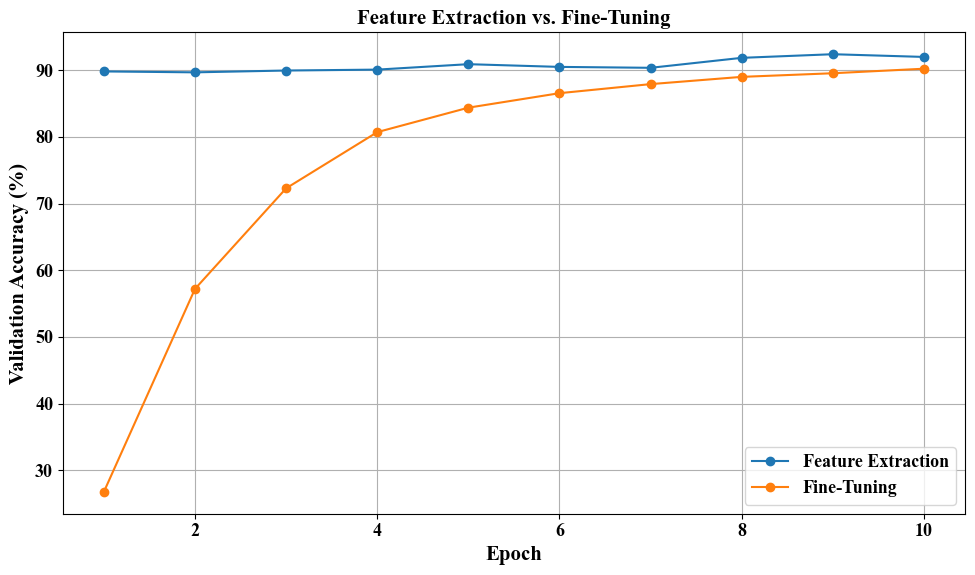

In [71]:
epochs = range(1, 11)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    np.array(feature_history.history["val_accuracy"]) * 100,
    marker="o",
    label="Feature Extraction"
)

plt.plot(
    epochs,
    np.array(fine_tune_history.history["val_accuracy"]) * 100,
    marker="o",
    label="Fine-Tuning"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Feature Extraction vs. Fine-Tuning")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Feature_Extraction_vs_Fine_Tuning.eps",format="eps",dpi=600)
plt.show()

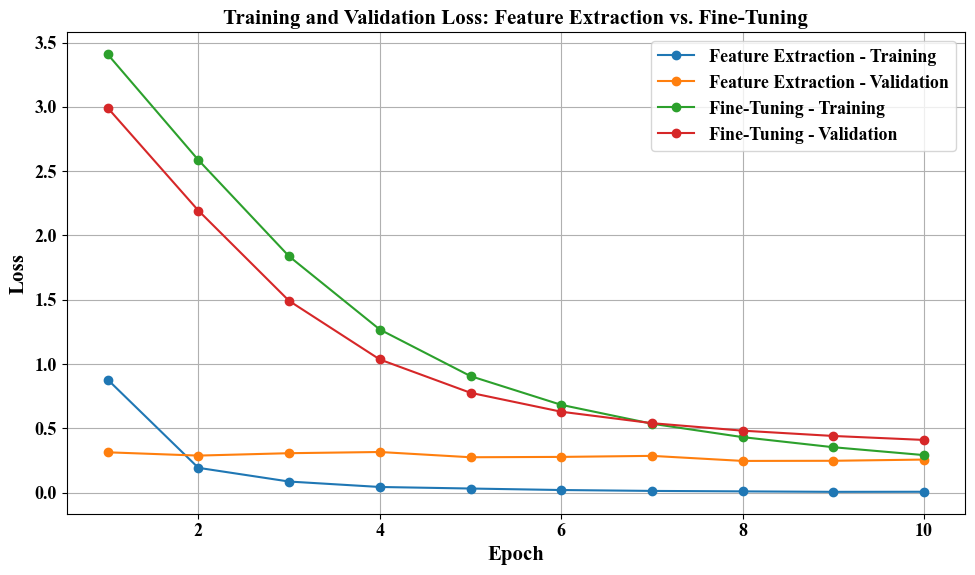

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    feature_history.history["loss"],
    marker="o",
    label="Feature Extraction - Training"
)

plt.plot(
    epochs,
    feature_history.history["val_loss"],
    marker="o",
    label="Feature Extraction - Validation"
)

plt.plot(
    epochs,
    fine_tune_history.history["loss"],
    marker="o",
    label="Fine-Tuning - Training"
)

plt.plot(
    epochs,
    fine_tune_history.history["val_loss"],
    marker="o",
    label="Fine-Tuning - Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss: Feature Extraction vs. Fine-Tuning")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Training_and_Validation_Loss_Feature Extraction_vs_Fine_Tuning.eps",format="eps",dpi=600)
plt.show()

In [79]:
X_train = []
y_train = []

for images, labels in train_ds:
    X_train.append(images.numpy())
    y_train.append(labels.numpy())

X_train = np.concatenate(X_train, axis=0)
y_train = np.concatenate(y_train, axis=0)

print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Number of training samples:", len(X_train))
print("Number of classes:", len(np.unique(y_train)))
print("Classes:", np.unique(y_train))

Training data shape: (2944, 224, 224, 3)
Training labels shape: (2944,)
Number of training samples: 2944
Number of classes: 37
Classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36]


In [80]:
configurations = {
    "C1": {
        "learning_rate": 0.001,
        "batch_size": 64,
        "dropout_rate": 0.5,
        "optimizer": "Adam"
    },
    "C2": {
        "learning_rate": 0.001,
        "batch_size": 64,
        "dropout_rate": 0.25,
        "optimizer": "Adam"
    },
    "C3": {
        "learning_rate": 0.001,
        "batch_size": 32,
        "dropout_rate": 0.5,
        "optimizer": "Adam"
    },
    "C4": {
        "learning_rate": 0.001,
        "batch_size": 64,
        "dropout_rate": 0.5,
        "optimizer": "Momentum"
    }
}

In [81]:
def create_cv_model(learning_rate, dropout_rate, optimizer_name):
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = False

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(224, 224, 3)),
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(37, activation="softmax")
    ])

    if optimizer_name == "Adam":
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        )
    elif optimizer_name == "Momentum":
        optimizer = tf.keras.optimizers.SGD(
            learning_rate=learning_rate,
            momentum=0.9
        )
    else:
        optimizer = tf.keras.optimizers.SGD(
            learning_rate=learning_rate
        )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [82]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = {}

for config_name, config in configurations.items():

    print("\n" + "=" * 60)
    print(config_name)
    print("=" * 60)

    fold_accuracies = []
    config_start = time.time()

    for fold, (train_idx, val_idx) in enumerate(
        skf.split(X_train, y_train), 1
    ):

        print(f"\nFold {fold}/5")

        X_fold_train = X_train[train_idx]
        y_fold_train = y_train[train_idx]

        X_fold_val = X_train[val_idx]
        y_fold_val = y_train[val_idx]

        train_fold = tf.data.Dataset.from_tensor_slices(
            (X_fold_train, y_fold_train)
        )

        val_fold = tf.data.Dataset.from_tensor_slices(
            (X_fold_val, y_fold_val)
        )

        train_fold = train_fold.shuffle(
            len(X_fold_train),
            seed=42
        ).batch(
            config["batch_size"]
        ).prefetch(
            tf.data.AUTOTUNE
        )

        val_fold = val_fold.batch(
            config["batch_size"]
        ).prefetch(
            tf.data.AUTOTUNE
        )

        model = create_cv_model(
            learning_rate=config["learning_rate"],
            dropout_rate=config["dropout_rate"],
            optimizer_name=config["optimizer"]
        )

        history = model.fit(
            train_fold,
            validation_data=val_fold,
            epochs=10,
            verbose=1
        )

        best_accuracy = max(
            history.history["val_accuracy"]
        )

        fold_accuracies.append(best_accuracy)

        print(
            f"Fold {fold} Best Validation Accuracy: "
            f"{best_accuracy * 100:.2f}%"
        )

        del model
        tf.keras.backend.clear_session()

    mean_accuracy = np.mean(fold_accuracies)
    std_accuracy = np.std(fold_accuracies)

    config_time = time.time() - config_start

    cv_results[config_name] = {
        "fold_accuracies": fold_accuracies,
        "mean_accuracy": mean_accuracy,
        "std_accuracy": std_accuracy,
        "time": config_time
    }

    print("\n" + "-" * 60)
    print(f"{config_name} Results")
    print("-" * 60)
    print(
        "Fold Accuracies:",
        [f"{x * 100:.2f}%" for x in fold_accuracies]
    )
    print(
        f"Mean Accuracy: {mean_accuracy * 100:.2f}%"
    )
    print(
        f"Standard Deviation: {std_accuracy * 100:.2f}%"
    )
    print(
        f"Mean ± SD: {mean_accuracy * 100:.2f}% ± "
        f"{std_accuracy * 100:.2f}%"
    )
    print(
        f"Time: {config_time:.2f} seconds"
    )


C1

Fold 1/5
Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 13s 313ms/step - accuracy: 0.3902 - loss: 2.3158 - val_accuracy: 0.8268 - val_loss: 0.8157
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 295ms/step - accuracy: 0.7380 - loss: 0.8912 - val_accuracy: 0.8812 - val_loss: 0.4928
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 289ms/step - accuracy: 0.8399 - loss: 0.5368 - val_accuracy: 0.8846 - val_loss: 0.4019
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 294ms/step - accuracy: 0.8769 - loss: 0.4184 - val_accuracy: 0.8964 - val_loss: 0.3808
Epoch 5/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 309ms/step - accuracy: 0.9015 - loss: 0.3336 - val_accuracy: 0.8981 - val_loss: 0.3659
Epoch 6/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 292ms/step - accuracy: 0.9248 - loss: 0.2652 - val_accuracy: 0.9066 - val_loss: 0.3439
Epoch 7/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 291ms/step - accuracy: 0.9282 - loss: 0.2371 - val_accuracy: 0.9032 - val_loss: 0.3404
Epoch 8/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 297ms/step - accuracy: 0.9372 - loss: 0.2

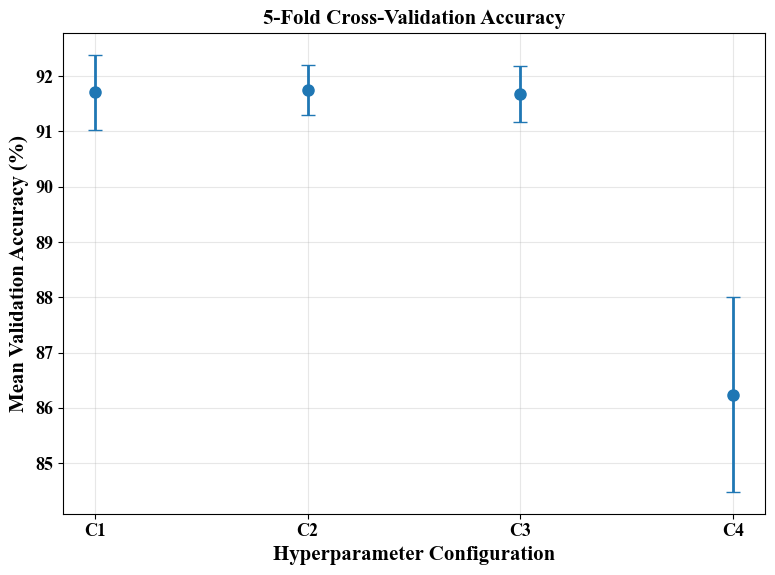

In [83]:
configs = ["C1", "C2", "C3", "C4"]

mean_accuracy = [91.71, 91.75, 91.68, 86.24]
std_accuracy = [0.68, 0.45, 0.51, 1.76]

plt.figure(figsize=(8, 6))

plt.errorbar(
    configs,
    mean_accuracy,
    yerr=std_accuracy,
    fmt='o',
    capsize=5,
    linewidth=2,
    markersize=8
)

plt.xlabel("Hyperparameter Configuration")
plt.ylabel("Mean Validation Accuracy (%)")
plt.title("5-Fold Cross-Validation Accuracy")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("cv_accuracy.eps", format="eps", dpi=600)
plt.show()

In [84]:
final_model = create_cv_model(
    learning_rate=0.001,
    dropout_rate=0.25,
    optimizer_name="Adam"
)

final_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,725 (9.26 MB)

 Trainable params: 168,741 (659.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [87]:
start_time = time.time()
final_history = final_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    verbose=1
)
final_training_time = time.time() - start_time
print("Final model training time:", final_training_time, "seconds")

Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 12s 228ms/step - accuracy: 0.5761 - loss: 1.6491
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 244ms/step - accuracy: 0.8702 - loss: 0.4369
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 12s 254ms/step - accuracy: 0.9103 - loss: 0.2846
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 236ms/step - accuracy: 0.9395 - loss: 0.1988
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 12s 256ms/step - accuracy: 0.9558 - loss: 0.1506
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 14s 306ms/step - accuracy: 0.9667 - loss: 0.1163
Epoch 7/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 17s 360ms/step - accuracy: 0.9749 - loss: 0.0937
Epoch 8/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 21s 452ms/step - accuracy: 0.9823 - loss: 0.0758
Epoch 9/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 26s 560ms/step - accuracy: 0.9918 - loss: 0.0604
Epoch 10/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 27s 591ms/step - accuracy: 0.9901 - loss: 0.0525
Final model training time: 162.80916714668274 seconds


In [89]:
X_test = []
y_test = []

for images, labels in test_ds:
    X_test.append(images.numpy())
    y_test.append(labels.numpy())

X_test = np.concatenate(X_test)
y_test = np.concatenate(y_test)

print("Test data shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

Test data shape: (3669, 224, 224, 3)
Test labels shape: (3669,)


In [90]:
test_loss, test_accuracy = final_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Accuracy :", test_accuracy)
print("Test Loss :", test_loss)

115/115 ━━━━━━━━━━━━━━━━━━━━ 17s 143ms/step - accuracy: 0.8942 - loss: 0.3607
Test Accuracy : 0.8942491412162781
Test Loss : 0.3607117235660553


In [92]:
y_pred_prob = final_model.predict(X_test, verbose=1)

y_pred = np.argmax(y_pred_prob, axis=1)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Precision :", precision)
print("Recall :", recall)
print("F1-score :", f1)

115/115 ━━━━━━━━━━━━━━━━━━━━ 14s 116ms/step
Precision : 0.8978852572218506
Recall : 0.8942491142000545
F1-score : 0.8937147162520471


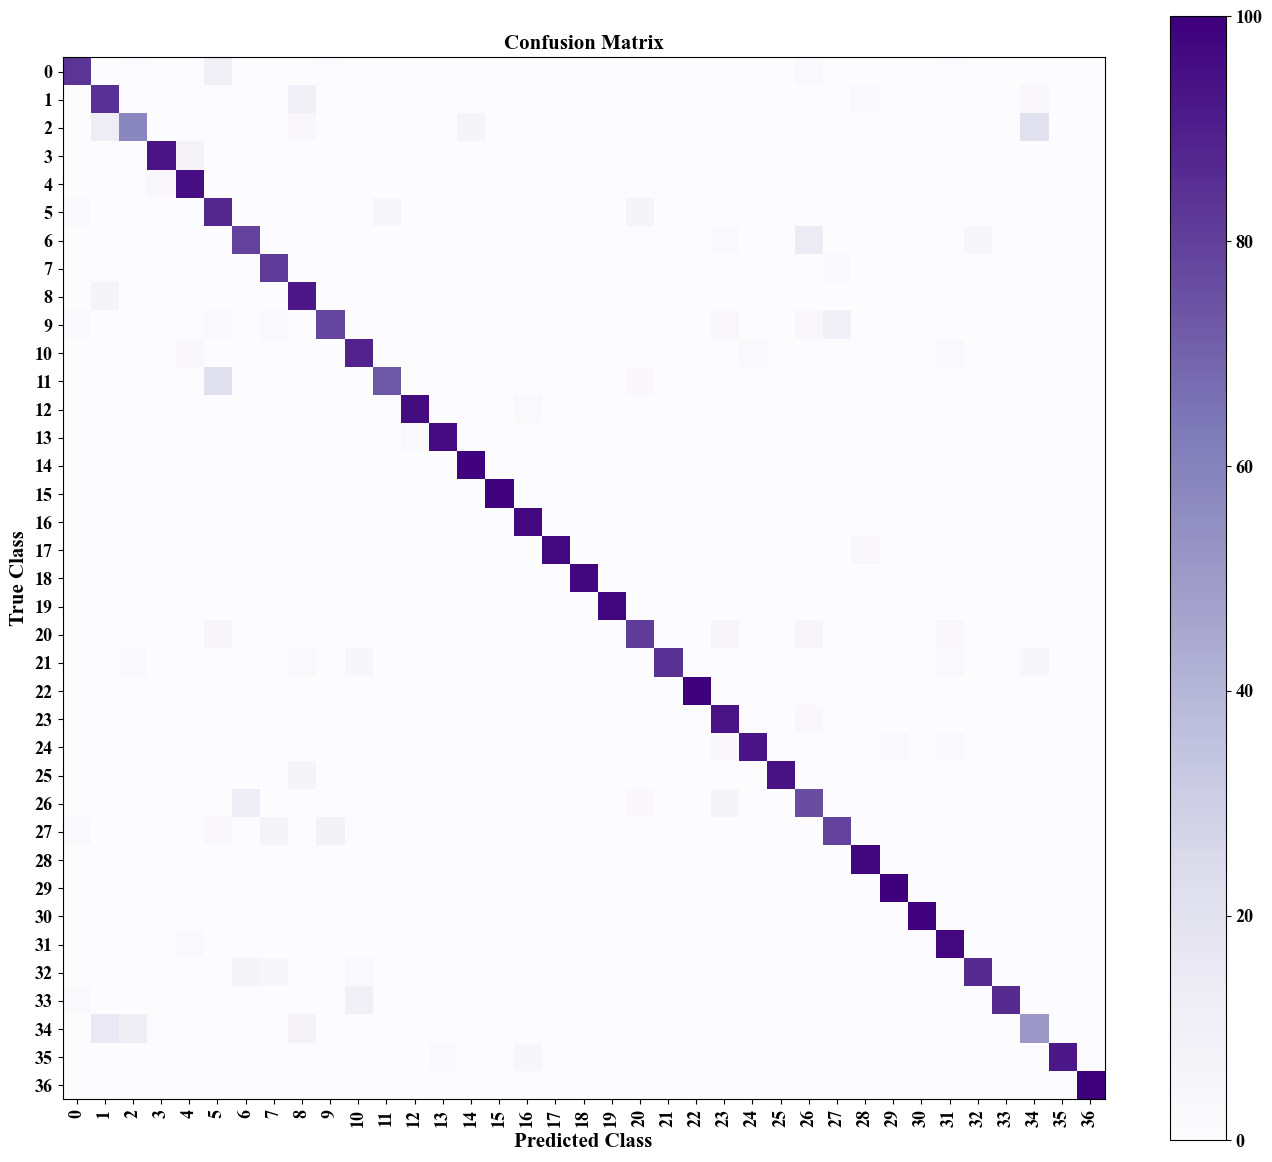

In [95]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 12))
plt.imshow(cm, cmap="Purples")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.colorbar()
plt.xticks(
    np.arange(37),
    np.arange(37),
    rotation=90
)
plt.yticks(
    np.arange(37),
    np.arange(37)
)
plt.tight_layout()
plt.savefig("confusion_matrix.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

In [96]:
class_names = ds_info.features["label"].names
print("Number of classes:", len(class_names))
for i, name in enumerate(class_names):
    print(i, name)

Number of classes: 37
0 Abyssinian
1 american_bulldog
2 american_pit_bull_terrier
3 basset_hound
4 beagle
5 Bengal
6 Birman
7 Bombay
8 boxer
9 British_Shorthair
10 chihuahua
11 Egyptian_Mau
12 english_cocker_spaniel
13 english_setter
14 german_shorthaired
15 great_pyrenees
16 havanese
17 japanese_chin
18 keeshond
19 leonberger
20 Maine_Coon
21 miniature_pinscher
22 newfoundland
23 Persian
24 pomeranian
25 pug
26 Ragdoll
27 Russian_Blue
28 saint_bernard
29 samoyed
30 scottish_terrier
31 shiba_inu
32 Siamese
33 Sphynx
34 staffordshire_bull_terrier
35 wheaten_terrier
36 yorkshire_terrier


Total misclassified images: 388


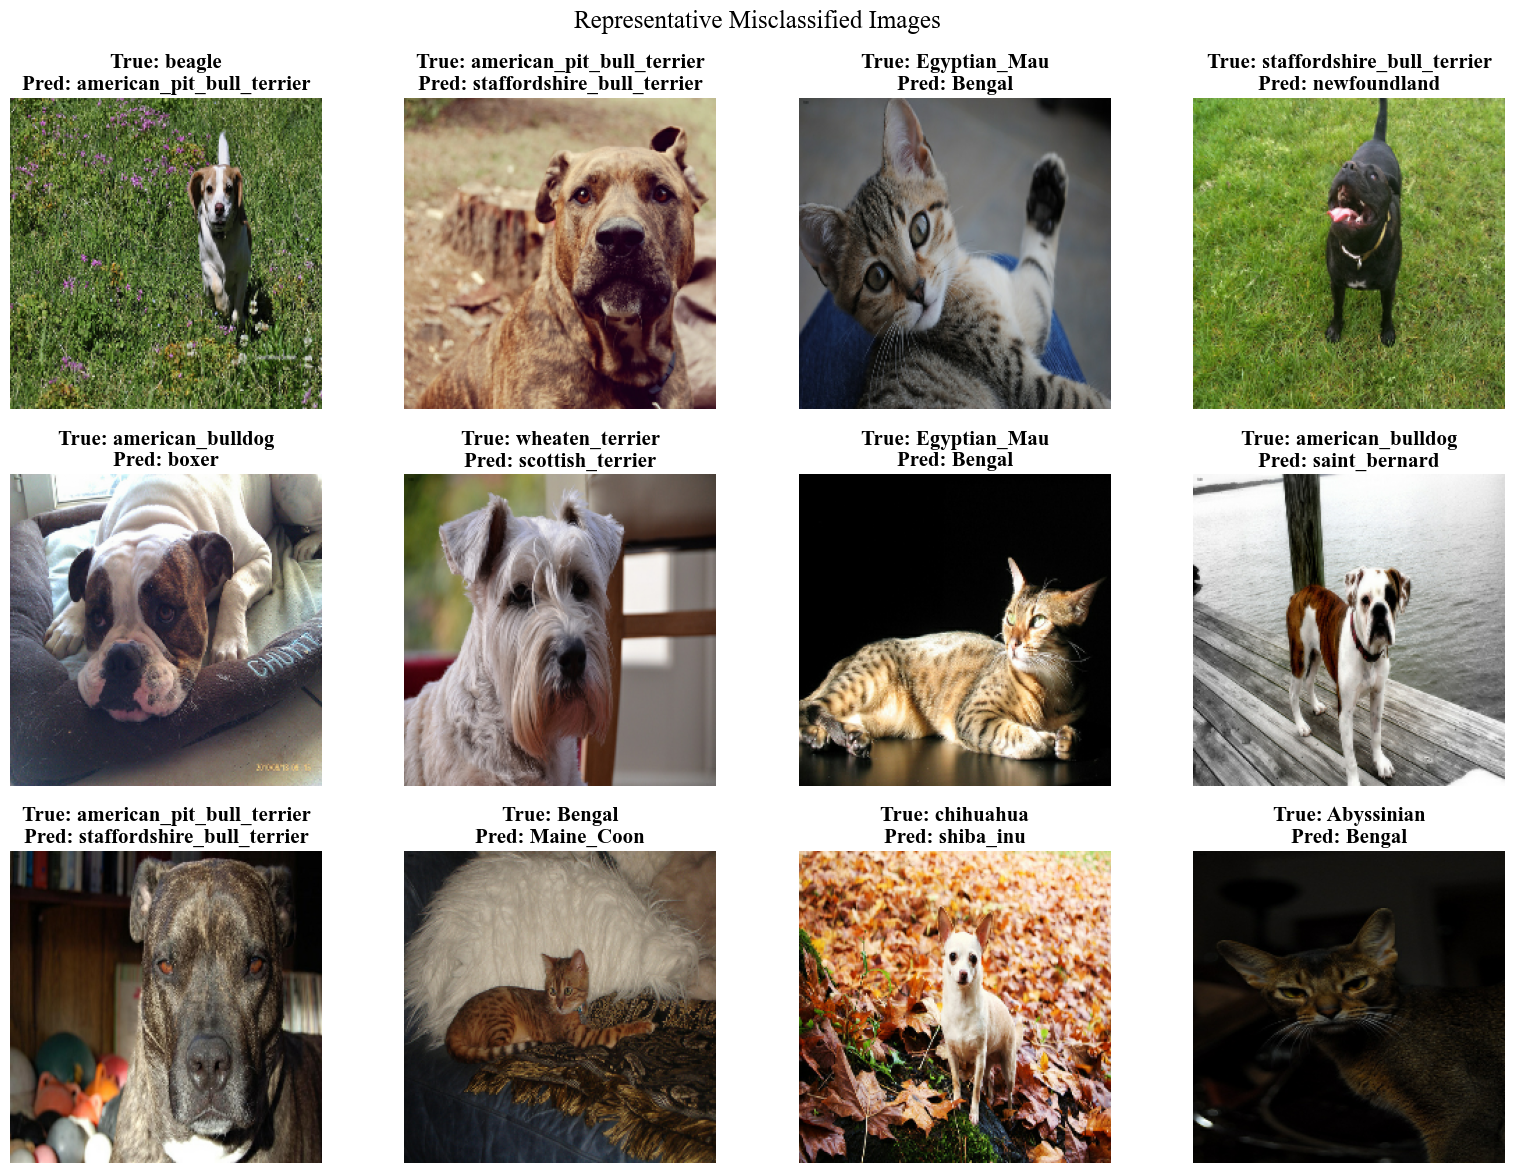

In [97]:
misclassified = np.where(y_pred != y_test)[0]
print("Total misclassified images:", len(misclassified))
np.random.seed(42)
selected_indices = np.random.choice(
    misclassified,
    size=min(12, len(misclassified)),
    replace=False
)
plt.figure(figsize=(16, 12))
for i, idx in enumerate(selected_indices):
    plt.subplot(3, 4, i + 1)
    image = X_test[idx]
    image_display = (image + 1.0) / 2.0
    image_display = np.clip(image_display, 0, 1)
    plt.imshow(image_display)
    true_class = class_names[y_test[idx]]
    predicted_class = class_names[y_pred[idx]]
    plt.title(
        f"True: {true_class}\nPred: {predicted_class}",
    )
    plt.axis("off")
plt.suptitle("Representative Misclassified Images",)
plt.tight_layout()
plt.savefig("misclassified_images.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

Additional Exercise

In [99]:
new_configurations = {
    "N1": {
        "learning_rate": 0.0001,
        "batch_size": 64,
        "dropout_rate": 0.25,
        "optimizer": "Adam",
        "fine_tune": False
    },
    "N2": {
        "learning_rate": 0.001,
        "batch_size": 32,
        "dropout_rate": 0.5,
        "optimizer": "Adam",
        "fine_tune": False
    }
}

In [100]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

new_cv_results = {}

for config_name, config in new_configurations.items():

    print("\n" + "=" * 60)
    print(config_name)
    print("=" * 60)

    fold_accuracies = []
    start_time = time.time()

    for fold, (train_idx, val_idx) in enumerate(
        skf.split(X_train, y_train), 1
    ):

        print(f"\nFold {fold}/5")

        model = create_cv_model(
            learning_rate=config["learning_rate"],
            dropout_rate=config["dropout_rate"],
            optimizer_name=config["optimizer"]
        )

        history = model.fit(
            X_train[train_idx],
            y_train[train_idx],
            validation_data=(
                X_train[val_idx],
                y_train[val_idx]
            ),
            epochs=10,
            batch_size=config["batch_size"],
            verbose=1
        )

        best_val_accuracy = max(
            history.history["val_accuracy"]
        )

        fold_accuracies.append(best_val_accuracy)

        print(
            f"Fold {fold} Accuracy: "
            f"{best_val_accuracy * 100:.2f}%"
        )

        del model
        tf.keras.backend.clear_session()

    mean_accuracy = np.mean(fold_accuracies)
    std_accuracy = np.std(fold_accuracies)

    training_time = time.time() - start_time

    new_cv_results[config_name] = {
        "fold_accuracies": fold_accuracies,
        "mean_accuracy": mean_accuracy,
        "std_accuracy": std_accuracy,
        "time": training_time
    }

    print("\n" + "-" * 60)
    print(f"{config_name} Results")
    print("-" * 60)

    print(
        "Fold Accuracies:",
        [f"{x * 100:.2f}%" for x in fold_accuracies]
    )

    print(
        f"Mean Accuracy: {mean_accuracy * 100:.2f}%"
    )

    print(
        f"Standard Deviation: {std_accuracy * 100:.2f}%"
    )

    print(
        f"Mean ± SD: "
        f"{mean_accuracy * 100:.2f}% ± "
        f"{std_accuracy * 100:.2f}%"
    )

    print(
        f"Time: {training_time:.2f} seconds"
    )


N1

Fold 1/5
Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 13s 315ms/step - accuracy: 0.0735 - loss: 3.5559 - val_accuracy: 0.1817 - val_loss: 3.1775
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 297ms/step - accuracy: 0.2616 - loss: 2.9602 - val_accuracy: 0.4720 - val_loss: 2.6446
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 12s 323ms/step - accuracy: 0.4675 - loss: 2.4010 - val_accuracy: 0.6553 - val_loss: 2.0694
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 294ms/step - accuracy: 0.6251 - loss: 1.8510 - val_accuracy: 0.7572 - val_loss: 1.5590
Epoch 5/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 298ms/step - accuracy: 0.6896 - loss: 1.4613 - val_accuracy: 0.8098 - val_loss: 1.1992
Epoch 6/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 12s 320ms/step - accuracy: 0.7648 - loss: 1.1228 - val_accuracy: 0.8421 - val_loss: 0.9632
Epoch 7/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 14s 375ms/step - accuracy: 0.7919 - loss: 0.9452 - val_accuracy: 0.8557 - val_loss: 0.8135
Epoch 8/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 15s 421ms/step - accuracy: 0.8144 - loss: 0.7